<a href="https://colab.research.google.com/github/shivanivishwa/my_trading_dashboard/blob/main/trading_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import requests

def download_file_from_google_drive(id, destination):
    URL = "https://docs.google.com/uc?export=download"
    session = requests.Session()
    response = session.get(URL, params = { 'id' : id }, stream = True)
    token = get_confirm_token(response)

    if token:
        params = { 'id' : id, 'confirm' : token }
        response = session.get(URL, params = params, stream = True)

    save_response_content(response, destination)

def get_confirm_token(response):
    for key, value in response.cookies.items():
        if key.startswith('download_warning'):
            return value
    return None

def save_response_content(response, destination):
    CHUNK_SIZE = 32768
    with open(destination, "wb") as f:
        for chunk in response.iter_content(CHUNK_SIZE):
            if chunk:
                f.write(chunk)

# Download Fear Greed Index dataset
file_id_fear_greed = '1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf'
destination_fear_greed = 'fear_greed_index.csv'
download_file_from_google_drive(file_id_fear_greed, destination_fear_greed)

# Load Fear Greed Index into a DataFrame
fear_greed_df = pd.read_csv(destination_fear_greed)

# Display the first 5 rows of the Fear Greed Index DataFrame
print("Fear Greed Index DataFrame Head:")
display(fear_greed_df.head())

Fear Greed Index DataFrame Head:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [19]:
import plotly.express as px

# Calculate daily average Closed PnL by sentiment classification
daily_pnl_by_sentiment = merged_df.groupby(['date', 'classification'])['Closed PnL'].mean().reset_index()
daily_pnl_by_sentiment.rename(columns={'Closed PnL': 'Daily Average PnL'}, inplace=True)

print("Daily Average PnL by Sentiment Classification Head:")
display(daily_pnl_by_sentiment.head())

Daily Average PnL by Sentiment Classification Head:


,date,classification,Daily Average PnL
0,2023-05-01,Greed,0.000000
1,2023-12-05,Extreme Greed,0.000000
2,2023-12-14,Greed,-18.675885
3,2023-12-15,Greed,-12.316017
4,2023-12-16,Greed,0.000000


### Interactive Line Chart: Daily Average PnL by Sentiment Classification

You can now download the `daily_pnl_by_sentiment_time_series.html` file from your Colab file browser and share it. Recipients can open this file directly in their web browser to view the interactive visualization.

In [22]:
import os

# Define the directory for the reports
reports_dir = 'trading_dashboard_reports'

# Create the directory if it doesn't exist
if not os.path.exists(reports_dir):
    os.makedirs(reports_dir)
    print(f"Directory '{reports_dir}' created.")
else:
    print(f"Directory '{reports_dir}' already exists.")


Directory 'trading_dashboard_reports' created.


In [23]:
import shutil

# List of HTML files to move
html_files = [
    'daily_pnl_by_sentiment_time_series.html',
    'pnl_sentiment_time_series.html',
    'sentiment_pnl_bar_chart.html'
]

# Move each file to the reports directory
for file_name in html_files:
    source_path = os.path.join('.', file_name)
    destination_path = os.path.join(reports_dir, file_name)
    if os.path.exists(source_path):
        shutil.move(source_path, destination_path)
        print(f"Moved '{file_name}' to '{reports_dir}'.")
    else:
        print(f"'{file_name}' not found. Skipping move.")

print(f"All specified HTML reports moved to '{reports_dir}'.")

Moved 'daily_pnl_by_sentiment_time_series.html' to 'trading_dashboard_reports'.
Moved 'pnl_sentiment_time_series.html' to 'trading_dashboard_reports'.
Moved 'sentiment_pnl_bar_chart.html' to 'trading_dashboard_reports'.
All specified HTML reports moved to 'trading_dashboard_reports'.


In [38]:
# Replace YOUR_GITHUB_REPO_URL with the HTTPS URL of your GitHub repository
github_repo_url = "https://github.com/shivanivishwa/my_trading_dashboard.git" # e.g., "https://github.com/your-username/your-repo-name.git"

# Add the remote origin


# Push the changes to GitHub
# You might be prompted for your GitHub username and Personal Access Token (PAT).
# If you encounter issues, ensure your PAT has the 'repo' scope and is correctly entered.
!git push -u origin main

print("Changes pushed to GitHub. You may need to enter your GitHub credentials if prompted.")

error: src refspec main does not match any
error: failed to push some refs to 'YOUR_GITHUB_REPO_URL'
Changes pushed to GitHub. You may need to enter your GitHub credentials if prompted.


In [40]:
!git branch

In [3]:
# Download Historical Trader Data dataset
file_id_trader_data = '1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs'
destination_trader_data = 'historical_trader_data.csv'
download_file_from_google_drive(file_id_trader_data, destination_trader_data)

# Load Historical Trader Data into a DataFrame
trader_df = pd.read_csv(destination_trader_data)

# Display the first 5 rows of the Historical Trader Data DataFrame
print("Historical Trader Data DataFrame Head:")
display(trader_df.head())

Historical Trader Data DataFrame Head:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
# Convert 'date' column in fear_greed_df to datetime objects
fear_greed_df['date'] = pd.to_datetime(fear_greed_df['date'])

# Convert 'Timestamp IST' and 'Timestamp' columns in trader_df to datetime objects
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True)
trader_df['Timestamp'] = pd.to_datetime(trader_df['Timestamp'], unit='ms') # Assuming 'Timestamp' is Unix timestamp in milliseconds

# Display updated DataFrame info to confirm data type changes
print("\nFear Greed Index DataFrame Info after conversion:")
fear_greed_df.info()

print("\nHistorical Trader Data DataFrame Info after conversion:")
trader_df.info()


Fear Greed Index DataFrame Info after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB

Historical Trader Data DataFrame Info after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens  

In [4]:
print("\nFear Greed Index DataFrame Info:")
fear_greed_df.info()

print("\nHistorical Trader Data DataFrame Info:")
trader_df.info()


Fear Greed Index DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB

Historical Trader Data DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Times

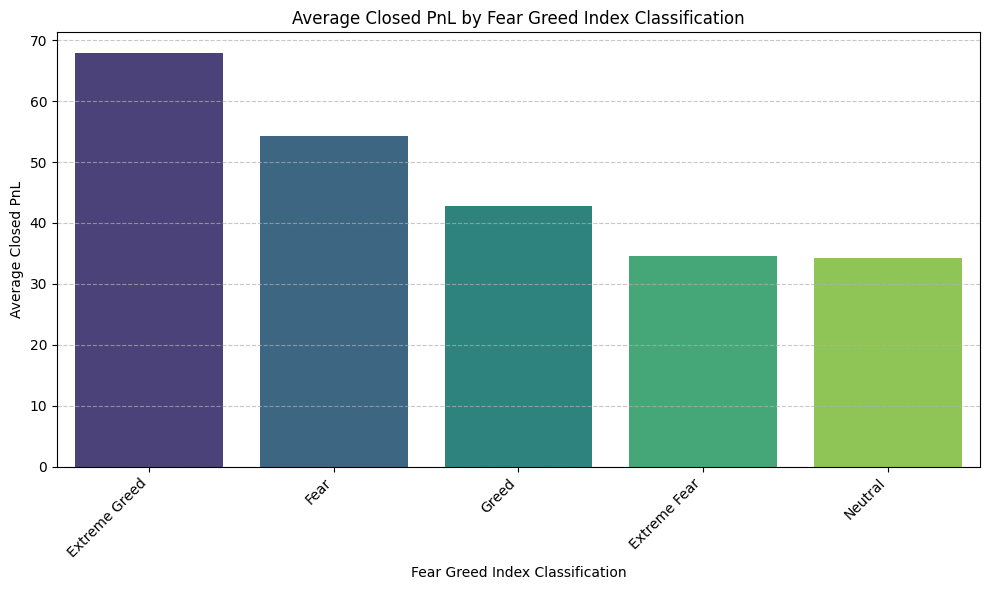

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for sentiment_pnl
plt.figure(figsize=(10, 6))
sns.barplot(x=sentiment_pnl.index, y=sentiment_pnl.values, hue=sentiment_pnl.index, palette='viridis', legend=False)
plt.title('Average Closed PnL by Fear Greed Index Classification')
plt.xlabel('Fear Greed Index Classification')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
# Calculate the average 'Closed PnL' for each 'classification'
sentiment_pnl = merged_df.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

print("Average Closed PnL by Fear Greed Index Classification:")
display(sentiment_pnl)

Average Closed PnL by Fear Greed Index Classification:


,Closed PnL
classification,
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Extreme Fear,34.537862
Neutral,34.307718


In [11]:
# Merge trader_df and fear_greed_df on the 'date' column
merged_df = pd.merge(trader_df, fear_greed_df, on='date', how='left', suffixes=('_trader', '_fear_greed'))

print("Merged DataFrame head:")
display(merged_df.head())

print("Merged DataFrame info:")
merged_df.info()

Merged DataFrame head:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-12-02,1.733117e+09,80.0,Extreme Greed


Merged DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  f

In [10]:
# Extract date from 'Timestamp IST' in trader_df for merging
trader_df['date'] = trader_df['Timestamp IST'].dt.date

# Convert the new 'date' column to datetime objects to match fear_greed_df's date dtype
trader_df['date'] = pd.to_datetime(trader_df['date'])

print("Trader DataFrame with new 'date' column head:")
display(trader_df.head())

print("Trader DataFrame info after adding 'date' column:")
trader_df.info()

Trader DataFrame with new 'date' column head:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-12-02


Trader DataFrame info after adding 'date' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee      

In [8]:
print("\nSummary statistics for Historical Trader Data DataFrame:")
display(trader_df.describe())


Summary statistics for Historical Trader Data DataFrame:


,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,211224
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,2025-01-24 18:44:50.421542912
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,2023-03-28 10:40:00
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,2025-02-19 21:20:00
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,2025-02-19 21:20:00
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,2025-02-19 21:20:00
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,2025-06-15 15:06:40
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,NaN


In [9]:
print("\nSummary statistics for Fear Greed Index DataFrame:")
display(fear_greed_df.describe())


Summary statistics for Fear Greed Index DataFrame:


,timestamp,value,date
count,2.644000e+03,2644.000000,2644
mean,1.631899e+09,46.981089,2021-09-17 11:44:45.022692864
min,1.517463e+09,5.000000,2018-02-01 00:00:00
25%,1.574811e+09,28.000000,2019-11-26 18:00:00
50%,1.631900e+09,46.000000,2021-09-17 12:00:00
75%,1.688989e+09,66.000000,2023-07-10 06:00:00
max,1.746164e+09,95.000000,2025-05-02 00:00:00
std,6.597967e+07,21.827680,NaN


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [15]:
import plotly.express as px
import plotly.graph_objects as go

# --- 1. Interactive Bar Chart: Average Closed PnL by Fear Greed Index Classification ---
# Ensure sentiment_pnl is a DataFrame for Plotly Express
sentiment_pnl_df = sentiment_pnl.reset_index()
sentiment_pnl_df.columns = ['Classification', 'Average Closed PnL']

fig_bar = px.bar(
    sentiment_pnl_df,
    x='Classification',
    y='Average Closed PnL',
    title='Interactive: Average Closed PnL by Fear Greed Index Classification',
    color='Classification',
    color_discrete_sequence=px.colors.qualitative.Vivid,
    labels={'Classification': 'Fear Greed Classification', 'Average Closed PnL': 'Average Closed PnL ($)'}
)

fig_bar.update_layout(xaxis_title_text='Fear Greed Classification', yaxis_title_text='Average Closed PnL ($)')
fig_bar.show()

In [16]:
# --- 2. Interactive Time Series: Daily Average PnL vs. Fear Greed Index Value ---

# Calculate daily average Closed PnL from the merged_df
daily_avg_pnl = merged_df.groupby('date')['Closed PnL'].mean().reset_index()
daily_avg_pnl.rename(columns={'Closed PnL': 'Daily Average PnL'}, inplace=True)

# Merge with fear_greed_df to get the index value for each date
time_series_df = pd.merge(daily_avg_pnl, fear_greed_df[['date', 'value']], on='date', how='left')

# Create a dual-axis time series plot
fig_ts = go.Figure()

# Add trace for Daily Average PnL
fig_ts.add_trace(go.Scatter(
    x=time_series_df['date'],
    y=time_series_df['Daily Average PnL'],
    mode='lines',
    name='Daily Average PnL',
    yaxis='y1'
))

# Add trace for Fear Greed Index Value
fig_ts.add_trace(go.Scatter(
    x=time_series_df['date'],
    y=time_series_df['value'],
    mode='lines',
    name='Fear Greed Index Value',
    yaxis='y2'
))

# Create axis objects
fig_ts.update_layout(
    title_text='Interactive: Daily Average PnL and Fear Greed Index Over Time',
    xaxis_title_text='Date',
    yaxis=dict(
        title='Daily Average PnL ($)',
        side='left',
        showgrid=False
    ),
    yaxis2=dict(
        title='Fear Greed Index Value',
        side='right',
        overlaying='y',
        showgrid=False,
        range=[0, 100] # Assuming index ranges from 0-100
    ),
    hovermode='x unified'
)

fig_ts.show()

### Insights for Smarter Trading Strategies from the Interactive Dashboard:

With these interactive plots, you can explore the data to derive more specific strategies:

1.  **Sentiment-Driven Entry/Exit Points (Bar Chart):**
    *   The bar chart visually confirms that 'Extreme Greed' and 'Fear' classifications tend to correspond to higher average `Closed PnL`. This suggests that traders who can identify these sentiment extremes might be able to capitalize on them.
    *   **Strategy Idea:** Develop a strategy that leans into trades when the Fear Greed Index enters 'Extreme Greed' or 'Fear' zones, potentially using contrarian approaches or trend-following depending on the specific asset and context.
    *   The low `Closed PnL` during 'Neutral' sentiment periods might suggest reducing trading activity or adopting range-bound strategies during such times.

2.  **Timing and Volatility (Time Series Plot):**
    *   By zooming and panning on the time series plot, you can observe if specific spikes or dips in `Daily Average PnL` align with sharp changes or prolonged periods of high/low `Fear Greed Index` values.
    *   **Strategy Idea:** Look for correlations between the magnitude of the Fear Greed Index (not just its classification) and `Closed PnL`. For example, are traders more profitable when the index is rapidly changing, indicating high volatility and strong sentiment shifts? Or when it stays consistently in one extreme for a period?
    *   Compare the `PnL` trend with the `Fear Greed Index` trend. Does `PnL` tend to rise or fall *after* a certain sentiment pattern emerges?

By interactively exploring these visualizations, you can develop hypotheses about optimal trading conditions and backtest them further.